# Детектор AI-генерированного текста
## Обнаружение аномалий в синтаксических структурах и паттернах пунктуации

---

### Структура ноутбука

| Этап | Содержание |
|------|------------|
| **0** | Инициализация, загрузка данных |
| **1** | Извлечение лингвистических признаков (15 дескрипторов) |
| **2** | Статистическая верификация четырёх гипотез (Mann–Whitney U) |
| **3** | Обучение и оценка классификатора Random Forest |
| **4** | Интерпретация через SHAP и feature importance |
| **5** | Демонстрация интерпретируемого предсказания |

---

### Четыре гипотезы 

- **Г1** — Синтаксическая шаблонность: AI-тексты демонстрируют меньшее разнообразие POS-конструкций (CR-POS, уникальные триграммы)
- **Г2** — Пунктуационная однородность: AI-тексты имеют более предсказуемые и равномерные паттерны пунктуации (burstiness, энтропия, CV запятых)
- **Г3** — Стилистическая «гладкость»: AI-тексты характеризуются сниженным лексическим разнообразием и упрощёнными конструкциями (TTR, HLR, причастия)
- **Г4** — Семантико-структурное несоответствие: AI-тексты используют мелкие синтаксические деревья при номинальном стиле (глубина, NV-ratio)

## Этап 0. Инициализация

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_curve, auc, confusion_matrix,
    precision_recall_curve, average_precision_score,
    classification_report
)
from scipy import stats

from src.features import get_syntactic_features, FEATURE_NAMES, N_FEATURES
from src.model import AICoreDetector, THRESHOLDS

# --- Единый стиль графиков ---
PALETTE = {0: '#2c7bb6', 1: '#d7191c'}   # синий=Human, красный=AI
CLASS_LABELS = {0: 'Human', 1: 'AI'}
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
sns.set_theme(style='whitegrid', palette='muted')

print(f'Python {sys.version}')
print(f'Число признаков: {N_FEATURES}')
print('Признаки:', FEATURE_NAMES)

Python 3.13.12 (main, Feb  4 2026, 15:06:39) [GCC 15.2.0]
Число признаков: 15
Признаки: ['avg_sent_len', 'burstiness', 'punct_entropy', 'punct_density', 'avg_dep_depth', 'nv_ratio', 'ttr', 'hlr', 'complexity_ratio', 'passive_ratio', 'comma_cv', 'cr_pos', 'unique_trigrams_per_tok', 'pos_entropy', 'total_tokens']


In [2]:
# --- Загрузка датасета ---
# Ожидаемый формат: CSV с колонками 'text' и 'is_ai' (0/1)
DATA_PATH = 'data/ai_detection_ru_dataset_v4.csv'

df = pd.read_csv(DATA_PATH)
assert 'text' in df.columns and 'is_ai' in df.columns, \
    "CSV должен содержать колонки 'text' и 'is_ai'"

# Удаляем пустые тексты и очень короткие записи
df = df.dropna(subset=['text'])
df = df[df['text'].str.len() >= 100].reset_index(drop=True)
df['is_ai'] = df['is_ai'].astype(int)

print(f'Итого записей для анализа: {len(df):,}')
print(f'\nРаспределение классов:')
vc = df['is_ai'].value_counts()
for label, cnt in vc.items():
    print(f'  {CLASS_LABELS[label]:6s}: {cnt:,} ({cnt/len(df):.1%})')

Итого записей для анализа: 9,995

Распределение классов:
  Human : 4,999 (50.0%)
  AI    : 4,996 (50.0%)


## Этап 1. Извлечение лингвистических признаков

Для каждого текста вычисляется вектор из **15 дескрипторов**, покрывающих все четыре гипотезы.  
Используется библиотека `spaCy` с моделью `ru_core_news_lg`.  
Признаки извлекаются **без учителя** — только лингвистический парсинг.

In [3]:
FEATURES_CACHE = 'cache/features_cache.npy'
LABELS_CACHE   = 'cache/labels_cache.npy'

if os.path.exists(FEATURES_CACHE) and os.path.exists(LABELS_CACHE):
    print('[Этап 1] Загружаем кэш признаков...')
    X = np.load(FEATURES_CACHE)
    y = np.load(LABELS_CACHE)
    print(f'  X.shape = {X.shape},  y.shape = {y.shape}')
else:
    print('[Этап 1] Извлечение признаков через spaCy (ru_core_news_lg)...')
    print(f'  Признаки: {FEATURE_NAMES}\n')

    tqdm.pandas(desc='Парсинг текстов')
    features_raw = df['text'].progress_apply(get_syntactic_features)

    X = np.array(features_raw.tolist(), dtype=np.float32)
    y = df['is_ai'].values

    # Заменяем NaN/Inf нулями (могут появиться на очень коротких текстах)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    os.makedirs('cache', exist_ok=True)
    np.save(FEATURES_CACHE, X)
    np.save(LABELS_CACHE, y)
    print(f'\n  X.shape = {X.shape}  →  сохранено в кэш')

# Добавляем признаки обратно в датафрейм для анализа
feat_df = pd.DataFrame(X, columns=FEATURE_NAMES)
feat_df['is_ai'] = y
print('\nСтатистика признаков:')
feat_df.describe().round(3)

[Этап 1] Загружаем кэш признаков...
  X.shape = (9995, 15),  y.shape = (9995,)

Статистика признаков:


,avg_sent_len,burstiness,punct_entropy,punct_density,avg_dep_depth,nv_ratio,ttr,hlr,complexity_ratio,passive_ratio,comma_cv,cr_pos,unique_trigrams_per_tok,pos_entropy,total_tokens,is_ai
count,9995.000,9995.000,9995.000,9995.000,9995.000,9.995000e+03,9995.000,9995.000,9995.000,9995.000,9995.000,9995.000,9995.000,9995.000,9995.00,9995.0
mean,20.358,6.918,1.747,0.161,5.128,3.791896e+07,0.646,0.484,0.021,0.159,0.657,0.223,0.573,2.858,273.46,0.5
std,21.035,7.379,0.479,0.044,4.059,3.202595e+09,0.123,0.139,0.014,0.118,0.208,0.048,0.130,0.259,265.94,0.5
min,2.495,0.000,-0.000,0.008,1.275,0.000000e+00,0.031,0.000,0.000,0.000,0.000,0.028,0.014,0.088,16.00,0.0
25%,14.705,4.407,1.373,0.131,4.286,2.160000e+00,0.589,0.409,0.011,0.071,0.534,0.198,0.500,2.735,164.00,0.0
50%,17.077,5.769,1.791,0.155,4.909,2.636000e+00,0.662,0.493,0.019,0.140,0.640,0.219,0.578,2.874,218.00,0.0
75%,19.750,7.661,2.098,0.183,5.588,3.217000e+00,0.724,0.571,0.029,0.227,0.769,0.244,0.659,3.012,302.00,1.0
max,424.000,197.525,3.562,0.776,357.000,3.190000e+11,1.000,1.000,0.125,1.000,1.968,0.737,0.946,3.495,8492.00,1.0


## Этап 2. Статистическая верификация гипотез

Для каждого признака проверяем нулевую гипотезу H₀ «распределение признака одинаково в Human и AI классах» с помощью непараметрического **критерия Манна–Уитни (U-test)**.

Применяется поправка **Бонферрони** на множественное тестирование (α = 0.05 / 15 ≈ 0.003).  
Размер эффекта оценивается через **rank-biserial correlation** r = 1 – 2U/(n₁n₂).

In [4]:
alpha = 0.05
alpha_bonf = alpha / N_FEATURES

human_idx = feat_df['is_ai'] == 0
ai_idx    = feat_df['is_ai'] == 1

stat_rows = []
for feat in FEATURE_NAMES:
    h_vals = feat_df.loc[human_idx, feat].values
    a_vals = feat_df.loc[ai_idx, feat].values

    u_stat, p_val = stats.mannwhitneyu(h_vals, a_vals, alternative='two-sided')
    r_effect = 1 - 2 * u_stat / (len(h_vals) * len(a_vals))  # rank-biserial

    stat_rows.append({
        'Признак': feat,
        'Среднее Human': round(np.mean(h_vals), 4),
        'Среднее AI':    round(np.mean(a_vals), 4),
        'U-статистика':  round(u_stat, 1),
        'p-value':       p_val,
        'r (эффект)':    round(abs(r_effect), 3),
        'Значимо (Bonf)': p_val < alpha_bonf,
    })

stat_df = pd.DataFrame(stat_rows).sort_values('r (эффект)', ascending=False)

print(f'Уровень значимости (с поправкой Бонферрони): α = {alpha_bonf:.4f}\n')

# Цветовая разметка: зелёный = значимо
def _highlight_sig(row):
    color = 'background-color: #d4edda' if row['Значимо (Bonf)'] else ''
    return [color] * len(row)

stat_df.style \
    .apply(_highlight_sig, axis=1) \
    .format({'p-value': '{:.2e}', 'r (эффект)': '{:.3f}'})

Уровень значимости (с поправкой Бонферрони): α = 0.0033



,Признак,Среднее Human,Среднее AI,U-статистика,p-value,r (эффект),Значимо (Bonf)
2,punct_entropy,2.027700,1.466700,21058388.000000,0.00e+00,0.686,True
3,punct_density,0.175600,0.146500,18852366.000000,0.00e+00,0.510,True
1,burstiness,7.305800,6.530900,18510180.000000,0.00e+00,0.482,True
6,ttr,0.695000,0.596600,18491248.000000,0.00e+00,0.481,True
7,hlr,0.540900,0.427200,18438000.000000,0.00e+00,0.477,True
4,avg_dep_depth,4.608100,5.648600,6736374.500000,0.00e+00,0.461,True
12,unique_trigrams_per_tok,0.613100,0.533700,17135232.000000,0.00e+00,0.372,True
11,cr_pos,0.233400,0.211900,15816432.000000,0.00e+00,0.267,True
10,comma_cv,0.693700,0.620300,15477693.000000,0.00e+00,0.239,True
0,avg_sent_len,16.897400,23.820499,10122474.000000,0.00e+00,0.189,True


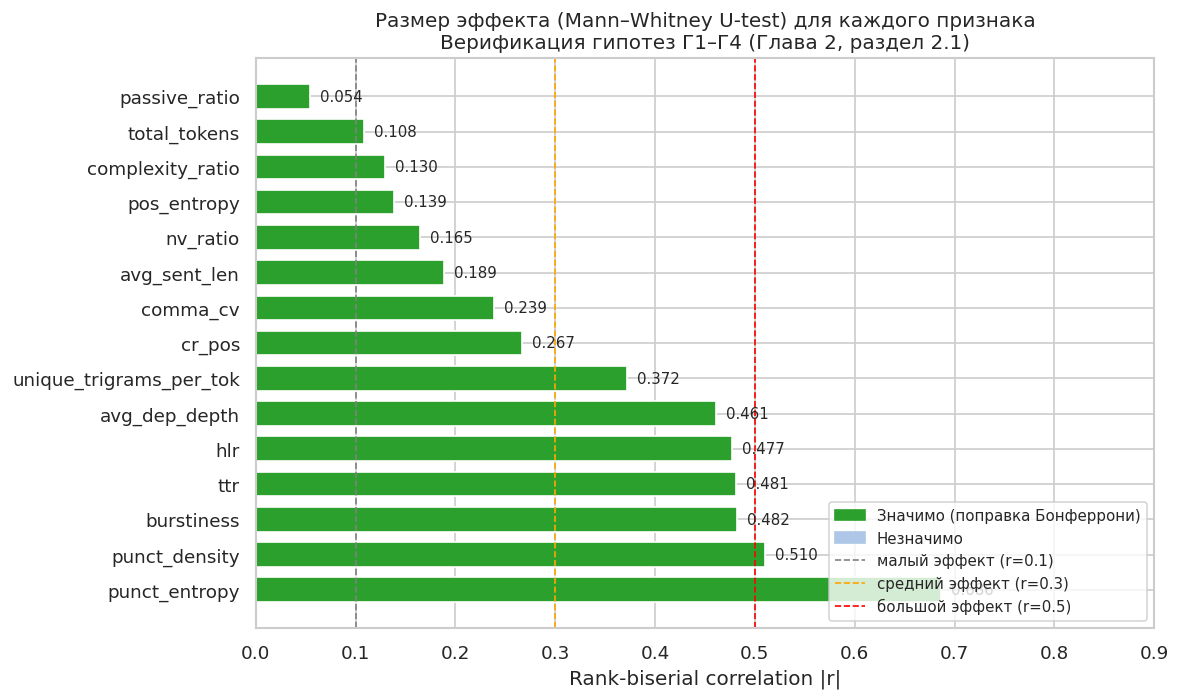

Значимых признаков (Бонферрони): 15 из 15


In [5]:
# --- Визуализация: размер эффекта по признакам ---
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ca02c' if sig else '#aec7e8'
          for sig in stat_df['Значимо (Bonf)']]

bars = ax.barh(stat_df['Признак'], stat_df['r (эффект)'],
               color=colors, edgecolor='white', height=0.7)

ax.axvline(x=0.1, color='gray', linestyle='--', lw=1, label='малый эффект (r=0.1)')
ax.axvline(x=0.3, color='orange', linestyle='--', lw=1, label='средний эффект (r=0.3)')
ax.axvline(x=0.5, color='red', linestyle='--', lw=1, label='большой эффект (r=0.5)')

sig_patch   = mpatches.Patch(color='#2ca02c', label='Значимо (поправка Бонферрони)')
insig_patch = mpatches.Patch(color='#aec7e8', label='Незначимо')
ax.legend(handles=[sig_patch, insig_patch] + ax.get_legend_handles_labels()[0][0:3],
          loc='lower right', fontsize=9)

ax.set_xlabel('Rank-biserial correlation |r|')
ax.set_title('Размер эффекта (Mann–Whitney U-test) для каждого признака\n'
             'Верификация гипотез Г1–Г4 (Глава 2, раздел 2.1)')
ax.set_xlim(0, 0.9)

for bar, val in zip(bars, stat_df['r (эффект)']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('figures/fig_effect_sizes.png', bbox_inches='tight')
plt.show()

sig_count = stat_df['Значимо (Bonf)'].sum()
print(f'Значимых признаков (Бонферрони): {sig_count} из {N_FEATURES}')

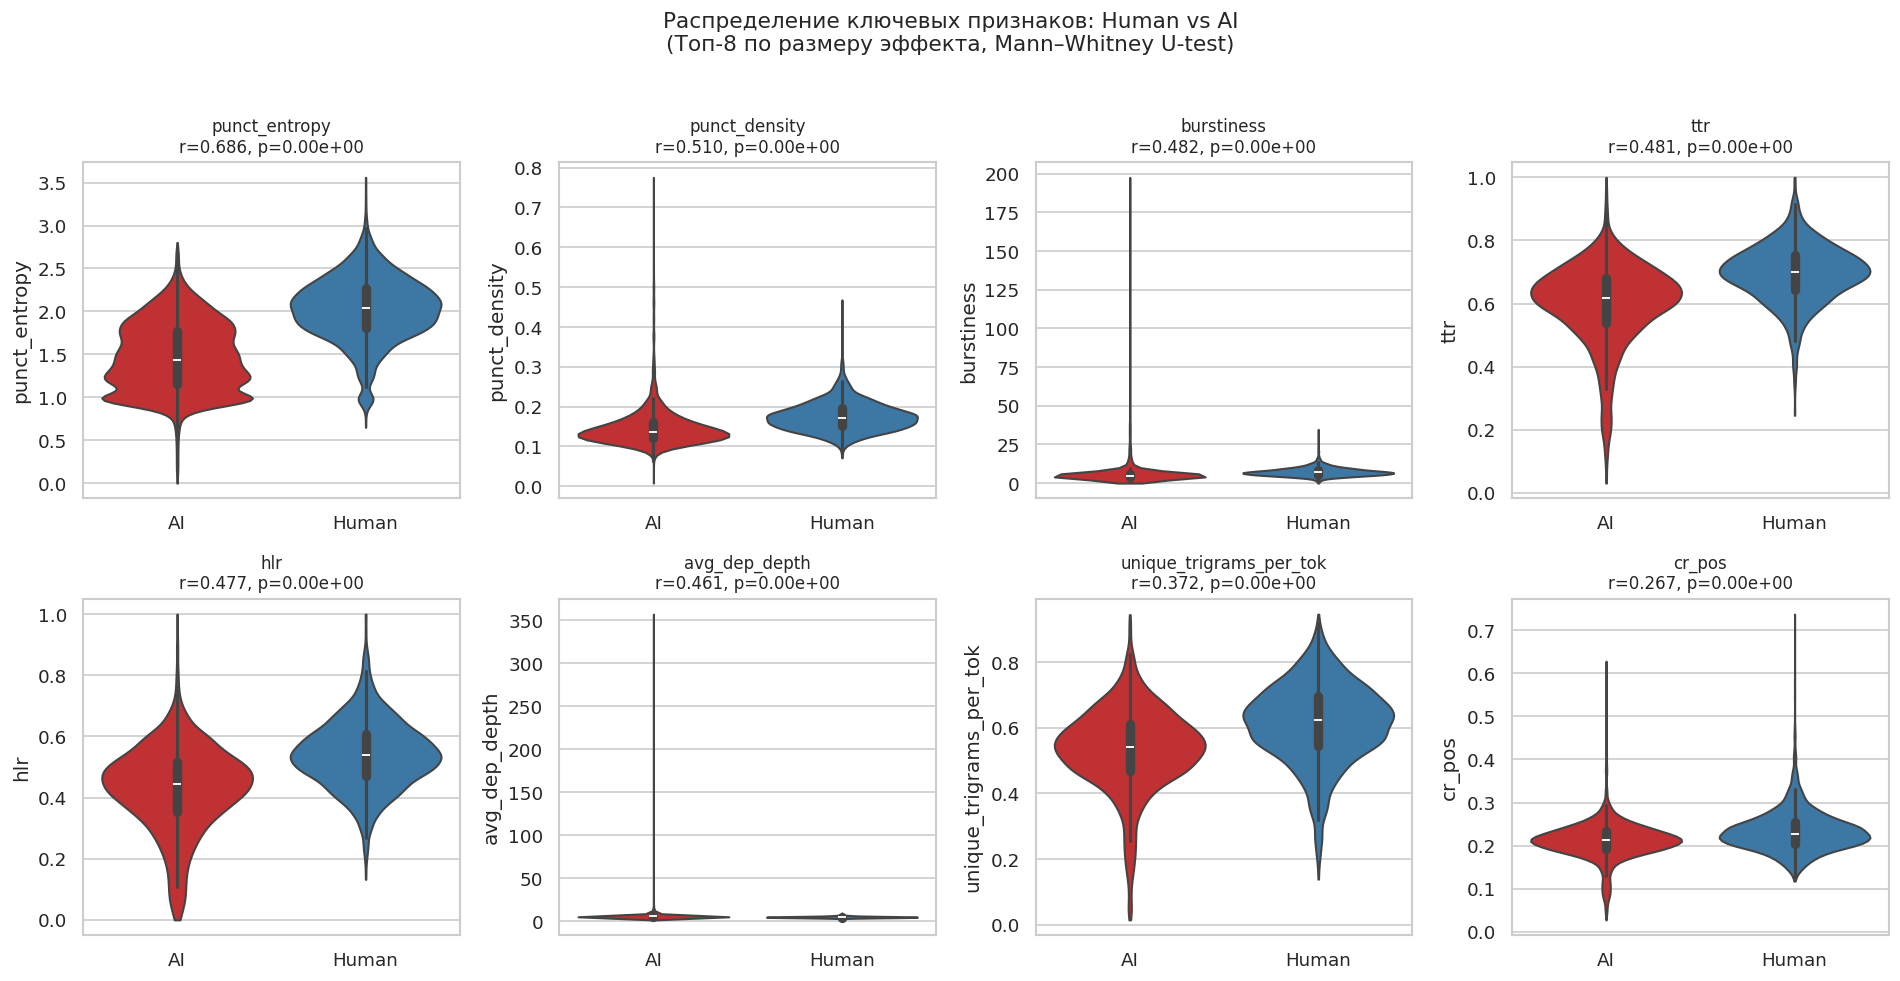

In [6]:
# --- Violin-plots: распределения ключевых признаков по классам ---
# Показываем топ-8 признаков по размеру эффекта
top_feats = stat_df.head(8)['Признак'].tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, feat in zip(axes, top_feats):
    plot_data = feat_df[['is_ai', feat]].copy()
    plot_data['Класс'] = plot_data['is_ai'].map(CLASS_LABELS)

    sns.violinplot(
        data=plot_data, x='Класс', y=feat, ax=ax,
        palette={'Human': '#2c7bb6', 'AI': '#d7191c'}, inner='box', cut=0, width=0.8
    )
    r_val = stat_df.loc[stat_df['Признак'] == feat, 'r (эффект)'].values[0]
    p_val = stat_df.loc[stat_df['Признак'] == feat, 'p-value'].values[0]
    ax.set_title(f'{feat}\nr={r_val:.3f}, p={p_val:.2e}', fontsize=10)
    ax.set_xlabel('')

fig.suptitle('Распределение ключевых признаков: Human vs AI\n'
             '(Топ-8 по размеру эффекта, Mann–Whitney U-test)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('figures/fig_violin_features.png', bbox_inches='tight')
plt.show()

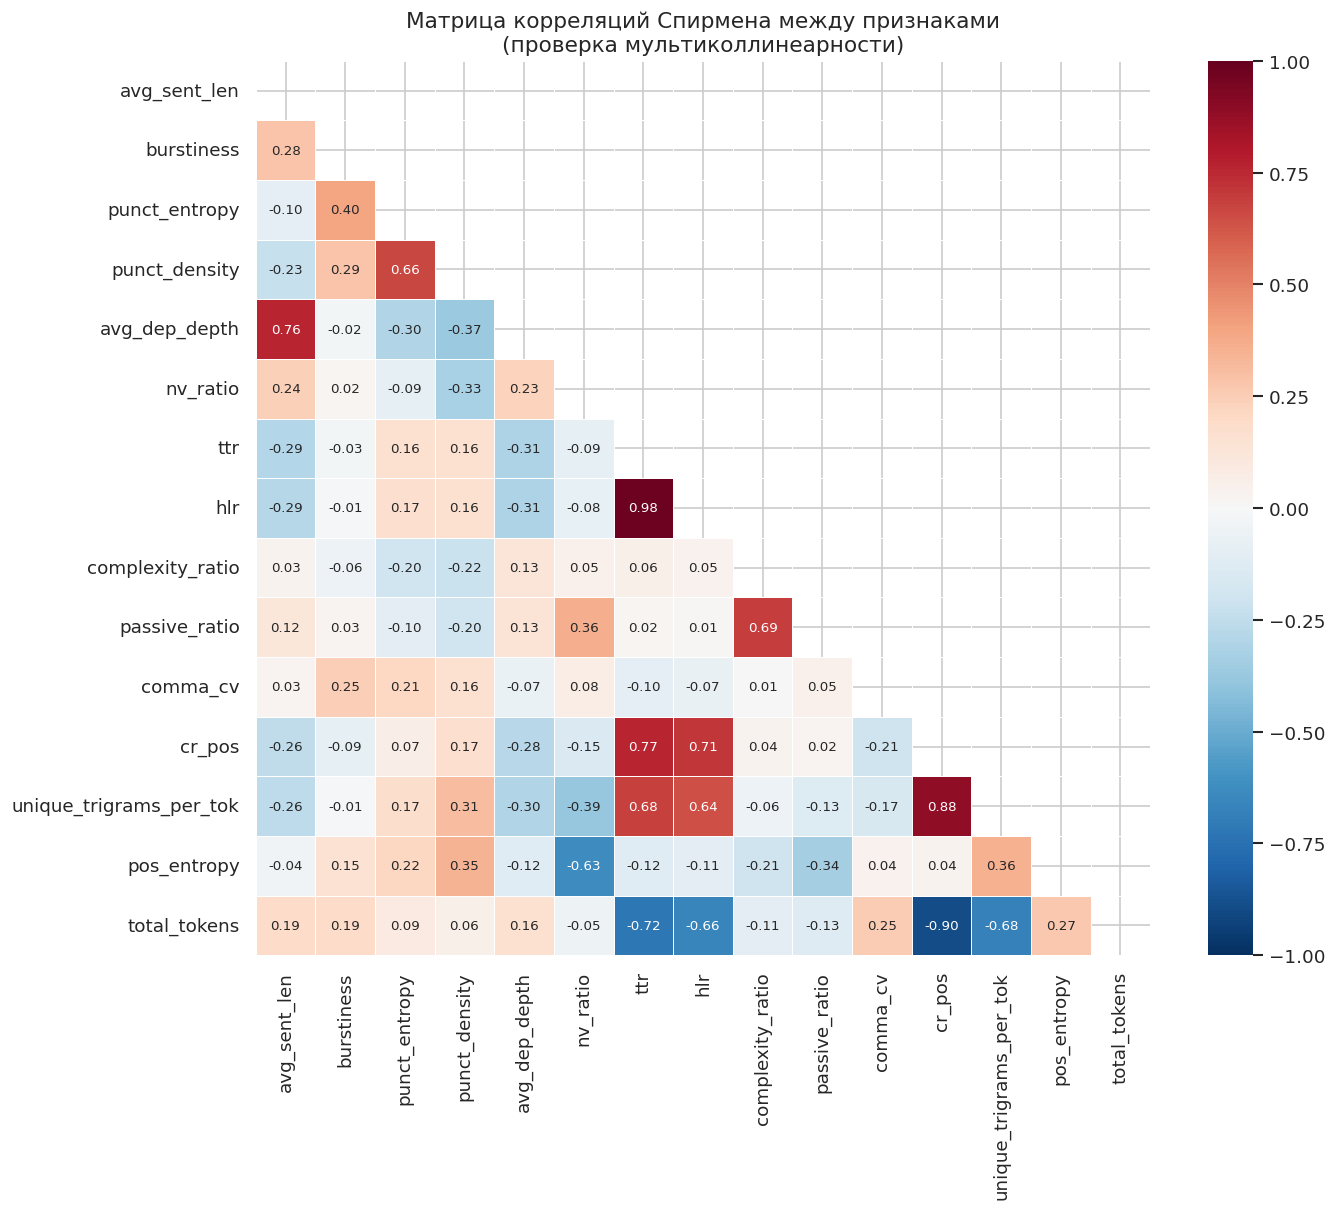

In [7]:
# --- Корреляционная матрица признаков ---
fig, ax = plt.subplots(figsize=(12, 10))
corr = feat_df[FEATURE_NAMES].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Матрица корреляций Спирмена между признаками\n'
             '(проверка мультиколлинеарности)', fontsize=13)
plt.tight_layout()
plt.savefig('figures/fig_correlation_matrix.png', bbox_inches='tight')
plt.show()

## Этап 3. Обучение и оценка классификатора

Используется **Random Forest** — интерпретируемый ансамблевый классификатор.  
Оценка качества: **5-кратная стратифицированная кросс-валидация** + hold-out тестовый набор (20%).  
Метрики: Accuracy, Precision, Recall, F1-score, AUC-ROC.

In [8]:
# --- Разбивка на train/test (стратифицированная) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]:,} примеров  |  Test: {X_test.shape[0]:,} примеров')
print(f'Баланс классов (train): Human={np.sum(y_train==0):,}, AI={np.sum(y_train==1):,}')

# --- 5-кратная кросс-валидация ---
print('\n[Этап 3] Кросс-валидация (5-fold, стратифицированная)...')
detector_cv = AICoreDetector()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    detector_cv.clf, X_train, y_train,
    cv=cv,
    scoring=['accuracy', 'f1', 'roc_auc', 'precision', 'recall'],
    return_train_score=False,
    n_jobs=-1
)

print('\nРезультаты кросс-валидации (mean ± std):')
cv_metrics = {
    'Accuracy':  cv_results['test_accuracy'],
    'Precision': cv_results['test_precision'],
    'Recall':    cv_results['test_recall'],
    'F1-Score':  cv_results['test_f1'],
    'AUC-ROC':   cv_results['test_roc_auc'],
}
for name, vals in cv_metrics.items():
    print(f'  {name:12s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}')

Train: 7,996 примеров  |  Test: 1,999 примеров
Баланс классов (train): Human=3,999, AI=3,997

[Этап 3] Кросс-валидация (5-fold, стратифицированная)...

Результаты кросс-валидации (mean ± std):
  Accuracy    : 0.9042 ± 0.0076
  Precision   : 0.9231 ± 0.0089
  Recall      : 0.8819 ± 0.0119
  F1-Score    : 0.9020 ± 0.0080
  AUC-ROC     : 0.9640 ± 0.0047


In [9]:
# --- Финальное обучение на полном train ---
print('[Этап 3] Финальное обучение модели на train-наборе...')
detector = AICoreDetector()
detector.train(X_train, y_train)

y_pred  = detector.predict(X_test)
y_probs = detector.predict_proba(X_test)[:, 1]

acc   = accuracy_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred)
rec   = recall_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

print(f'\nМетрики на тестовом наборе (hold-out 20%):')
print(f'  Accuracy : {acc:.4f}')
print(f'  Precision: {prec:.4f}')
print(f'  Recall   : {rec:.4f}')
print(f'  F1-Score : {f1:.4f}')
print(f'  AUC-ROC  : {roc_auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Human', 'AI']))

[Этап 3] Финальное обучение модели на train-наборе...

Метрики на тестовом наборе (hold-out 20%):
  Accuracy : 0.9025
  Precision: 0.9179
  Recall   : 0.8839
  F1-Score : 0.9006
  AUC-ROC  : 0.9613

              precision    recall  f1-score   support

       Human       0.89      0.92      0.90      1000
          AI       0.92      0.88      0.90       999

    accuracy                           0.90      1999
   macro avg       0.90      0.90      0.90      1999
weighted avg       0.90      0.90      0.90      1999



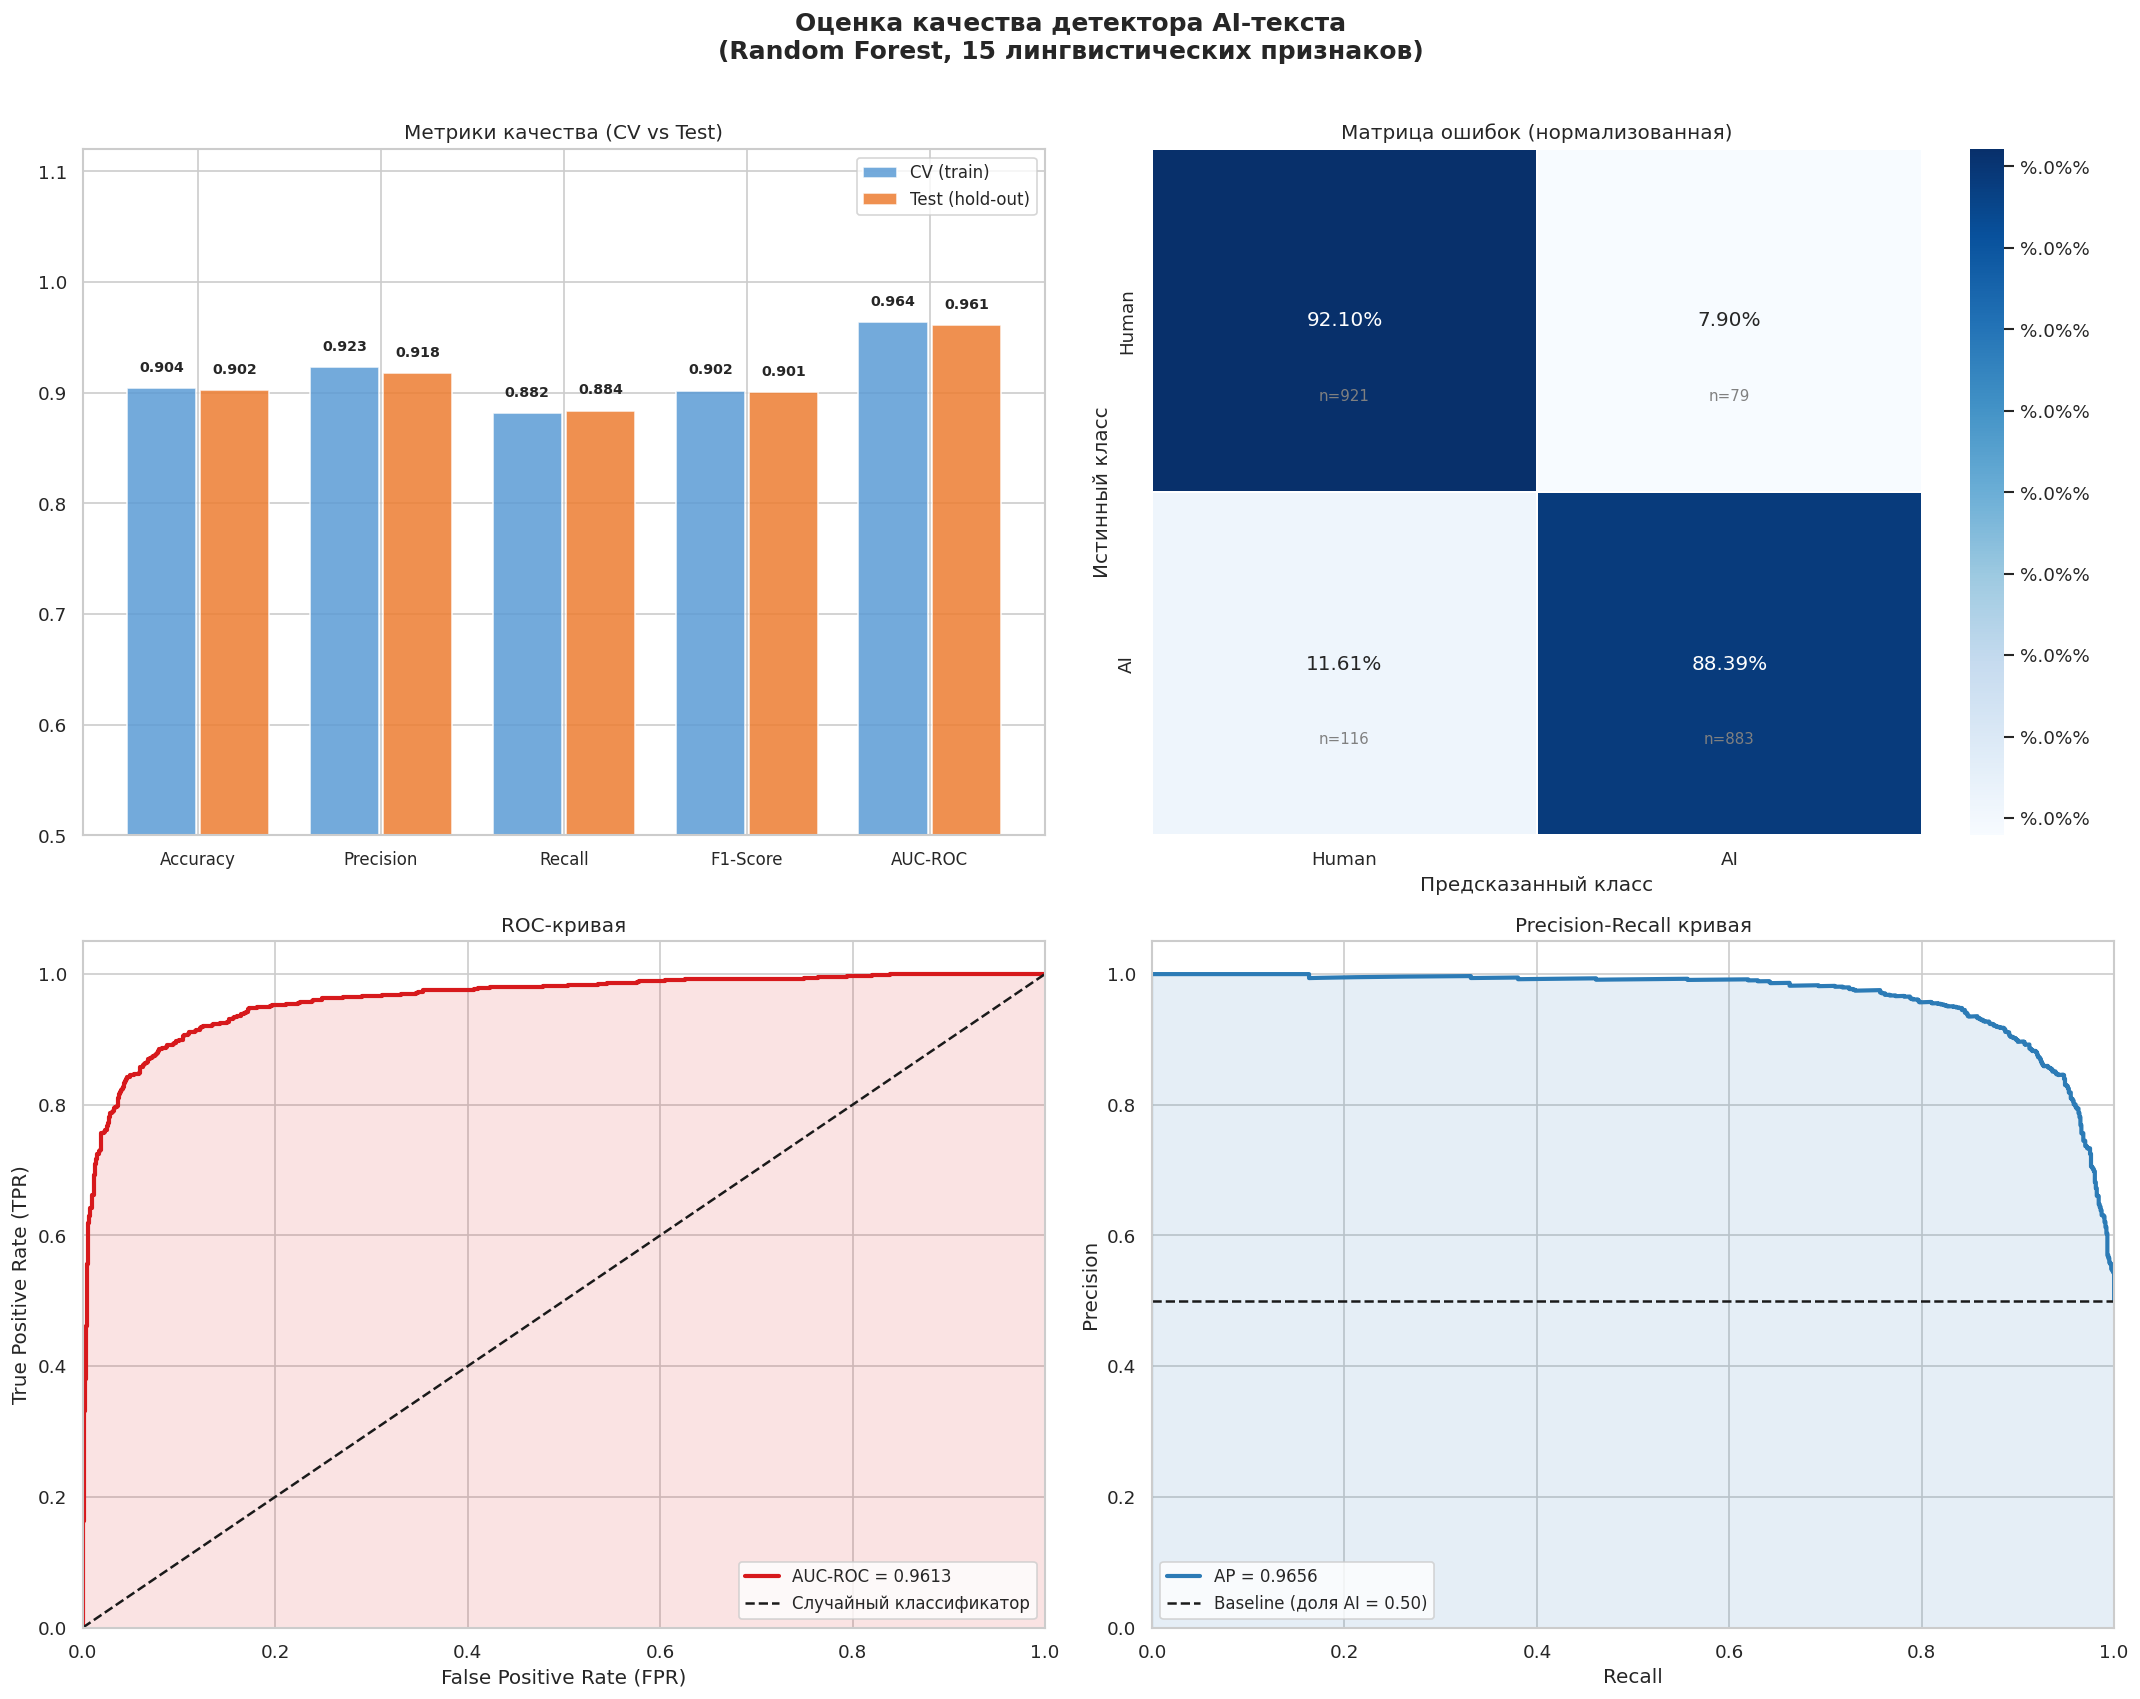


Итоговые метрики: F1=0.9006 | AUC-ROC=0.9613 | Accuracy=0.9025


In [10]:
# =====================================================================
# Итоговый дашборд: 4 графика качества классификации
# =====================================================================
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Оценка качества детектора AI-текста\n'
             '(Random Forest, 15 лингвистических признаков)',
             fontsize=15, fontweight='bold', y=1.01)

# --- 1. Сравнение кросс-валидации и тестового набора ---
ax1 = plt.subplot(2, 2, 1)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
cv_means      = [np.mean(cv_metrics[m]) for m in metrics_names]
test_vals     = [acc, prec, rec, f1, roc_auc]

x_pos = np.arange(len(metrics_names))
bars1 = ax1.bar(x_pos - 0.2, cv_means, 0.38, label='CV (train)', color='#5b9bd5', alpha=0.85)
bars2 = ax1.bar(x_pos + 0.2, test_vals, 0.38, label='Test (hold-out)', color='#ed7d31', alpha=0.85)
ax1.set_ylim(0.5, 1.12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(metrics_names, fontsize=10)
ax1.set_title('Метрики качества (CV vs Test)', fontsize=12)
ax1.legend(fontsize=10)
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.012,
             f'{h:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# --- 2. Матрица ошибок ---
ax2 = plt.subplot(2, 2, 2)
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=ax2,
    xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'],
    linewidths=1, linecolor='white', cbar_kws={'format': '%.0%%'}
)
# Добавляем абсолютные числа
for i in range(2):
    for j in range(2):
        ax2.text(j + 0.5, i + 0.72, f'n={cm[i,j]}',
                 ha='center', va='center', fontsize=9, color='grey')
ax2.set_title('Матрица ошибок (нормализованная)', fontsize=12)
ax2.set_xlabel('Предсказанный класс')
ax2.set_ylabel('Истинный класс')

# --- 3. ROC-кривая ---
ax3 = plt.subplot(2, 2, 3)
ax3.plot(fpr, tpr, color='#d7191c', lw=2.5, label=f'AUC-ROC = {roc_auc:.4f}')
ax3.fill_between(fpr, tpr, alpha=0.12, color='#d7191c')
ax3.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Случайный классификатор')
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('False Positive Rate (FPR)')
ax3.set_ylabel('True Positive Rate (TPR)')
ax3.set_title('ROC-кривая', fontsize=12)
ax3.legend(loc='lower right', fontsize=10)

# --- 4. Precision-Recall кривая ---
ax4 = plt.subplot(2, 2, 4)
pr_prec, pr_rec, _ = precision_recall_curve(y_test, y_probs)
avg_prec = average_precision_score(y_test, y_probs)
ax4.plot(pr_rec, pr_prec, color='#2c7bb6', lw=2.5,
         label=f'AP = {avg_prec:.4f}')
ax4.fill_between(pr_rec, pr_prec, alpha=0.12, color='#2c7bb6')
baseline = np.sum(y_test) / len(y_test)
ax4.axhline(y=baseline, color='k', linestyle='--', lw=1.5,
            label=f'Baseline (доля AI = {baseline:.2f})')
ax4.set_xlabel('Recall')
ax4.set_ylabel('Precision')
ax4.set_title('Precision-Recall кривая', fontsize=12)
ax4.legend(loc='lower left', fontsize=10)
ax4.set_xlim([0.0, 1.0])
ax4.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.savefig('figures/fig_classifier_performance.png', bbox_inches='tight')
plt.show()

print(f'\nИтоговые метрики: F1={f1:.4f} | AUC-ROC={roc_auc:.4f} | Accuracy={acc:.4f}')

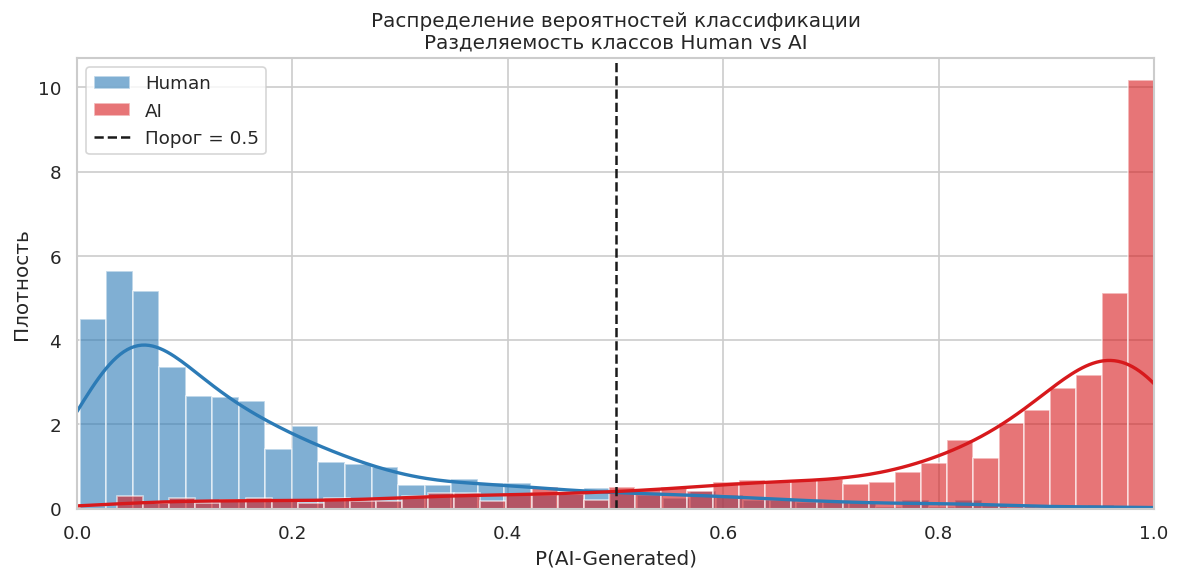

In [11]:
# --- Распределение вероятностей предсказания ---
fig, ax = plt.subplots(figsize=(10, 5))

for label, color, name in [(0, '#2c7bb6', 'Human'), (1, '#d7191c', 'AI')]:
    mask = y_test == label
    ax.hist(y_probs[mask], bins=40, alpha=0.6, color=color, label=name,
            density=True, edgecolor='white')
    # KDE
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(y_probs[mask])
    xs = np.linspace(0, 1, 300)
    ax.plot(xs, kde(xs), color=color, lw=2)

ax.axvline(x=0.5, color='k', linestyle='--', lw=1.5, label='Порог = 0.5')
ax.set_xlabel('P(AI-Generated)')
ax.set_ylabel('Плотность')
ax.set_title('Распределение вероятностей классификации\n'
             'Разделяемость классов Human vs AI')
ax.legend(fontsize=11)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig('figures/fig_prob_distribution.png', bbox_inches='tight')
plt.show()

## Этап 4. Интерпретация через Feature Importance и SHAP

Интерпретируемость — ключевое свойство предлагаемого метода.  
Используем два подхода:
1. **MDI Feature Importance** (Gini, встроен в RF) — глобальная важность
2. **SHAP (TreeExplainer)** — вклад каждого признака в конкретное решение

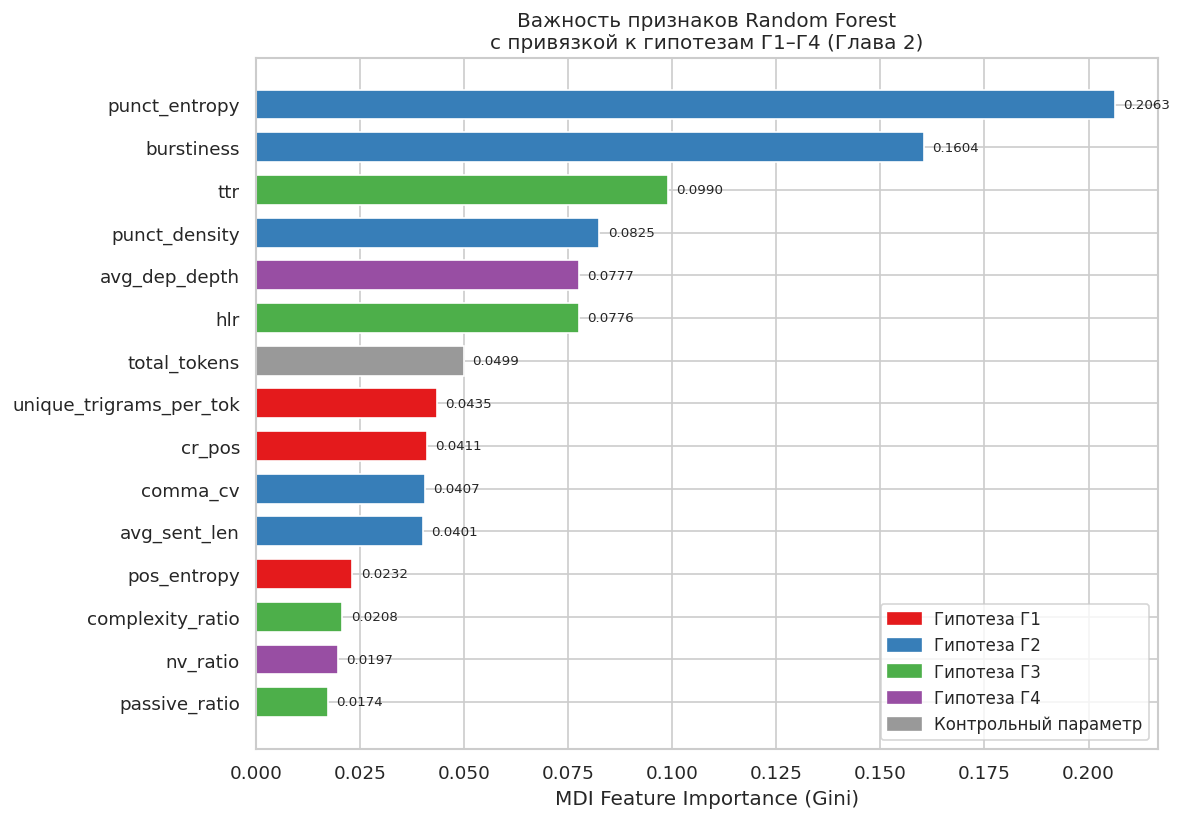

Топ-5 признаков по важности:
      Признак Гипотеза  Важность
punct_entropy       Г2  0.206283
   burstiness       Г2  0.160414
          ttr       Г3  0.099006
punct_density       Г2  0.082539
avg_dep_depth       Г4  0.077697


In [12]:
# --- 4A. Feature Importance (Gini / MDI) ---
importances = detector.get_feature_importances()
imp_df = pd.DataFrame({
    'Признак':   list(importances.keys()),
    'Важность':  list(importances.values()),
}).sort_values('Важность', ascending=True)

# Сопоставление с гипотезами
hyp_map = {
    'avg_sent_len': 'Г2', 'burstiness': 'Г2', 'punct_entropy': 'Г2',
    'punct_density': 'Г2', 'comma_cv': 'Г2',
    'avg_dep_depth': 'Г4', 'nv_ratio': 'Г4',
    'ttr': 'Г3', 'hlr': 'Г3', 'complexity_ratio': 'Г3', 'passive_ratio': 'Г3',
    'cr_pos': 'Г1', 'unique_trigrams_per_tok': 'Г1', 'pos_entropy': 'Г1',
    'total_tokens': 'Ctrl',
}
hyp_colors = {'Г1': '#e41a1c', 'Г2': '#377eb8', 'Г3': '#4daf4a',
              'Г4': '#984ea3', 'Ctrl': '#999999'}
imp_df['Гипотеза'] = imp_df['Признак'].map(hyp_map)
imp_df['color']    = imp_df['Гипотеза'].map(hyp_colors)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(imp_df['Признак'], imp_df['Важность'],
               color=imp_df['color'], edgecolor='white', height=0.7)

# Легенда
handles = [mpatches.Patch(color=c, label=f'Гипотеза {h}')
           for h, c in hyp_colors.items() if h != 'Ctrl']
handles.append(mpatches.Patch(color='#999999', label='Контрольный параметр'))
ax.legend(handles=handles, loc='lower right', fontsize=10)

for bar, val in zip(bars, imp_df['Важность']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

ax.set_xlabel('MDI Feature Importance (Gini)')
ax.set_title('Важность признаков Random Forest\n'
             'с привязкой к гипотезам Г1–Г4 (Глава 2)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/fig_feature_importance.png', bbox_inches='tight')
plt.show()

print('Топ-5 признаков по важности:')
print(imp_df.sort_values('Важность', ascending=False)[
    ['Признак', 'Гипотеза', 'Важность']].head(5).to_string(index=False))

[Этап 4] Вычисление SHAP values (TreeExplainer)...
  X_shap.shape  = (500, 15)
  sv_ai.shape   = (500, 15)


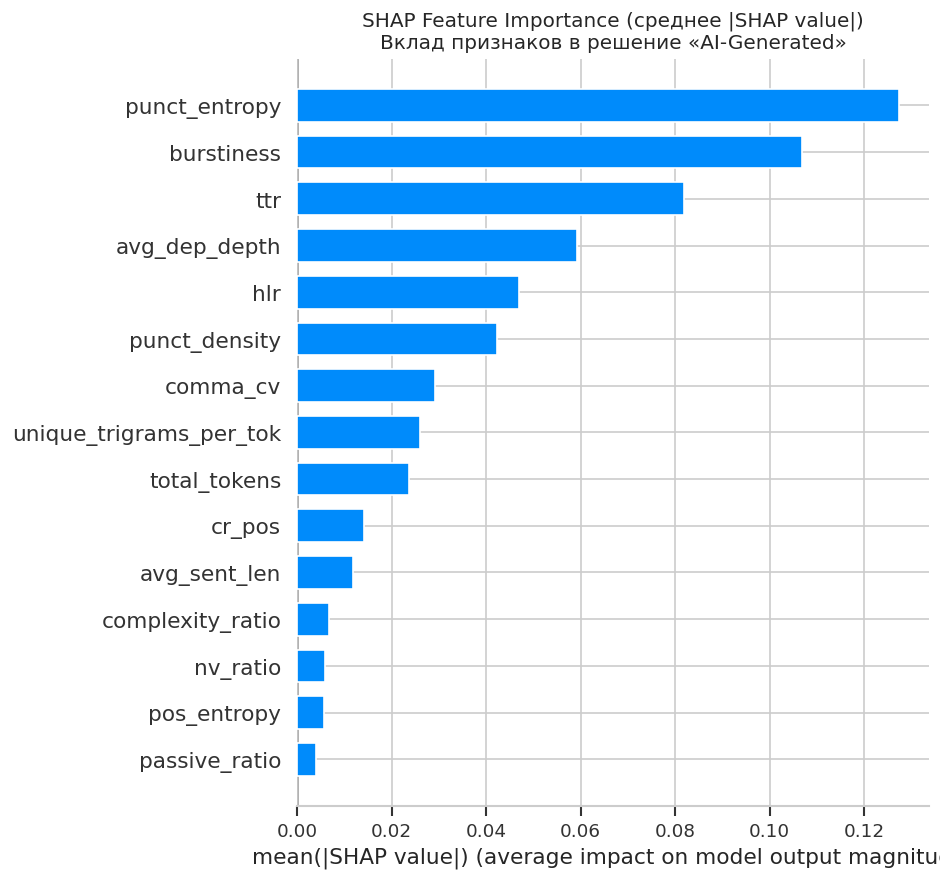

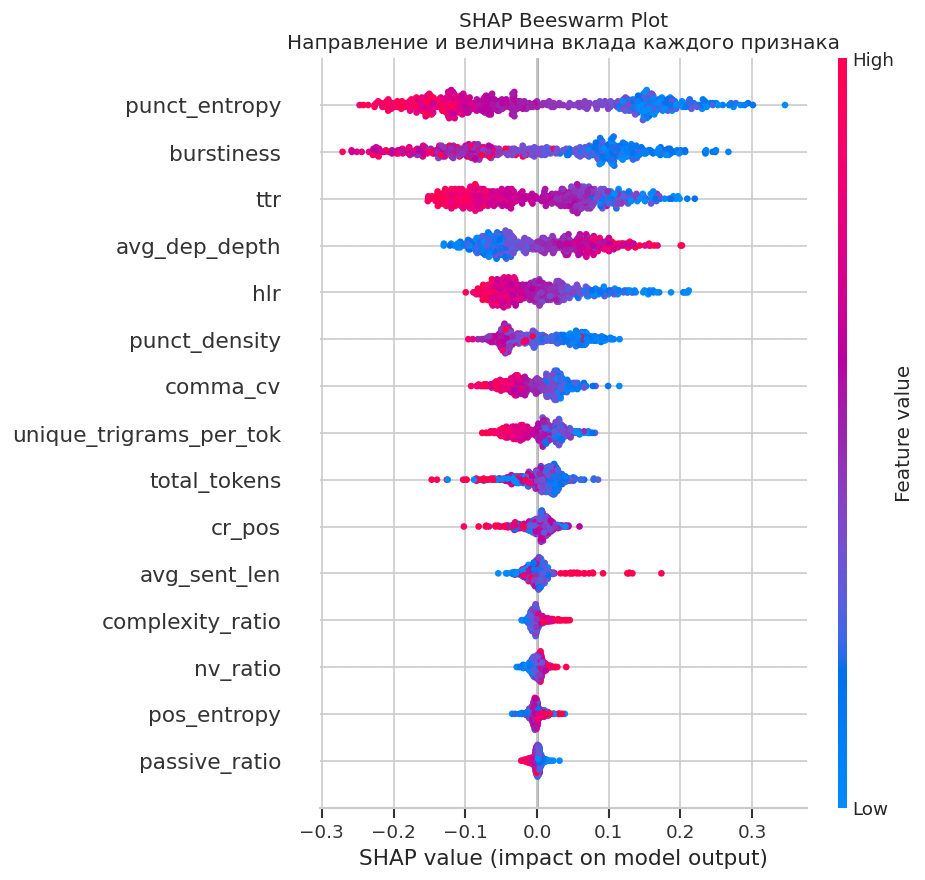


SHAP-анализ успешно завершён.


In [13]:
# --- 4B. SHAP Analysis (TreeExplainer) ---
try:
    import shap

    print('[Этап 4] Вычисление SHAP values (TreeExplainer)...')

    # Используем подвыборку для скорости (до 500 примеров)
    shap_sample_size = min(500, len(X_test))
    rng = np.random.default_rng(42)
    idx_shap = rng.choice(len(X_test), size=shap_sample_size, replace=False)
    X_shap = X_test[idx_shap]

    explainer   = shap.TreeExplainer(detector.clf)
    shap_values = explainer.shap_values(X_shap)

    # shap_values может быть списком [class0, class1] или 3D-массивом
    if isinstance(shap_values, list):
        sv_ai = shap_values[1]          # вклад в класс AI
    elif shap_values.ndim == 3:
        sv_ai = shap_values[:, :, 1]
    else:
        sv_ai = shap_values

    print(f'  X_shap.shape  = {X_shap.shape}')
    print(f'  sv_ai.shape   = {sv_ai.shape}')

    # --- График A: Bar plot (среднее |SHAP|) ---
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        sv_ai, X_shap,
        feature_names=FEATURE_NAMES,
        plot_type='bar',
        max_display=N_FEATURES,
        show=False
    )
    plt.title('SHAP Feature Importance (среднее |SHAP value|)\n'
              'Вклад признаков в решение «AI-Generated»', fontsize=12)
    plt.tight_layout()
    plt.savefig('figures/fig_shap_bar.png', bbox_inches='tight')
    plt.show()

    # --- График Б: Beeswarm plot ---
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        sv_ai, X_shap,
        feature_names=FEATURE_NAMES,
        max_display=N_FEATURES,
        show=False
    )
    plt.title('SHAP Beeswarm Plot\n'
              'Направление и величина вклада каждого признака', fontsize=12)
    plt.tight_layout()
    plt.savefig('figures/fig_shap_beeswarm.png', bbox_inches='tight')
    plt.show()

    print('\nSHAP-анализ успешно завершён.')

except ImportError:
    print('SHAP не установлен. Установите: pip install shap')
    print('Пропускаем SHAP-анализ; feature importance доступна выше.')
except Exception as e:
    print(f'Ошибка SHAP: {e}')
    print('Продолжаем без SHAP. MDI feature importance доступна выше.')

## Этап 5. Интерпретируемое предсказание для конкретных текстов

Демонстрируем работу метода `predict_with_explanation()`:  
каждый вывод модели сопровождается обоснованием через конкретные гипотезы.

In [14]:
from src.features import get_syntactic_features
from src.model import AICoreDetector
import pprint

def analyze_text(text: str, label: str = '') -> None:
    """Полный анализ и вывод результата для одного текста."""
    feats = get_syntactic_features(text)
    result = detector.predict_with_explanation(text, feats)

    sep = '─' * 70
    print(sep)
    if label:
        print(f'[Истинная метка: {label}]')
    print(f'Текст (первые 200 симв.): {text[:200]}...')
    print(sep)
    print(f'  ВЕРДИКТ    : {result["verdict"]}')
    print(f'  P(AI)      : {result["probability"]:.4f}')
    print(f'  Уверенность: {result["confidence_level"]}')
    print(f'  Сработало сигналов: {result["n_triggered_signals"]}\n')
    print('  Обнаруженные аномалии:')
    for i, reason in enumerate(result['reasons'], 1):
        print(f'    {i}. {reason}')
    print()
    print('  Ключевые значения признаков:')
    key_feats = ['burstiness', 'punct_entropy', 'comma_cv',
                 'cr_pos', 'ttr', 'hlr', 'avg_dep_depth', 'nv_ratio']
    for f in key_feats:
        print(f'    {f:28s}: {result["feature_values"][f]:.5f}')
    print(sep + '\n')


# --- Примеры из тестового набора ---
# Берём по одному уверенному примеру каждого класса
probs_test = detector.predict_proba(X_test)[:, 1]

# Самый уверенный «Human» (наименьшая P(AI))
confident_human_idx = np.where(y_test == 0)[0][
    np.argmin(probs_test[y_test == 0])
]
# Самый уверенный «AI» (наибольшая P(AI))
confident_ai_idx = np.where(y_test == 1)[0][
    np.argmax(probs_test[y_test == 1])
]

# Индексы в оригинальном датафрейме (test split воспроизводим)
df_test = df.iloc[df.index[len(df) - len(y_test):]]  # приблизительно

# Используем первые подходящие примеры напрямую из df
sample_human = df[df['is_ai'] == 0].iloc[confident_human_idx % len(df[df['is_ai']==0])]
sample_ai    = df[df['is_ai'] == 1].iloc[confident_ai_idx    % len(df[df['is_ai']==1])]

print('=== ДЕМОНСТРАЦИЯ ИНТЕРПРЕТИРУЕМОГО ПРЕДСКАЗАНИЯ ===')
print('=== (Уверенные примеры из тестового набора)     ===\n')

analyze_text(sample_human['text'], label='HUMAN')
analyze_text(sample_ai['text'],    label='AI')

=== ДЕМОНСТРАЦИЯ ИНТЕРПРЕТИРУЕМОГО ПРЕДСКАЗАНИЯ ===
=== (Уверенные примеры из тестового набора)     ===

──────────────────────────────────────────────────────────────────────
[Истинная метка: HUMAN]
Текст (первые 200 симв.): Лубянка" и "Парк  культуры" Сокольнической линии  произошли два мощных взрыва .   В 07.57 мск на станции метро "Лубянка" был осуществлен  взрыв  во втором вагоне электропоезда, следовавшего по маршрут...
──────────────────────────────────────────────────────────────────────
  ВЕРДИКТ    : Human-Written
  P(AI)      : 0.0200
  Уверенность: Высокая
  Сработало сигналов: 4

  Обнаруженные аномалии:
    1. [Г3] Низкий TTR (0.455 < 0.55): ограниченное лексическое разнообразие.
    2. [Г3] Низкий HLR (0.292 < 0.35): мало уникальных слов (hapax legomena) — бедный словарный запас.
    3. [Г3] Мало причастий/деепричастий (0.032 < 0.04): упрощённые синтаксические конструкции.
    4. [Г4] Высокий Noun/Verb Ratio (3.405 > 3.0): номинальный стиль — преобладание именных структу

In [15]:
# --- Анализ пограничных (сложных) случаев ---
print('=== ПОГРАНИЧНЫЕ СЛУЧАИ (0.4 < P(AI) < 0.6) ===\n')

borderline_mask = (probs_test > 0.4) & (probs_test < 0.6)
borderline_idx  = np.where(borderline_mask)[0]

print(f'Пограничных случаев в тестовом наборе: {borderline_mask.sum()}')
print(f'из них Human: {np.sum(y_test[borderline_mask]==0)}, '
      f'AI: {np.sum(y_test[borderline_mask]==1)}')

=== ПОГРАНИЧНЫЕ СЛУЧАИ (0.4 < P(AI) < 0.6) ===

Пограничных случаев в тестовом наборе: 158
из них Human: 79, AI: 79


In [16]:
# --- Сохранение модели ---
os.makedirs('cache', exist_ok=True)
detector.save('cache/syntactic_detector.pkl')
print('Модель сохранена в cache/syntactic_detector.pkl')

# --- Итоговая сводка ---
print('\n' + '='*70)
print('ИТОГОВАЯ СВОДКА ЭКСПЕРИМЕНТА')
print('='*70)
print(f'Датасет               : {len(df):,} текстов')
print(f'Признаков             : {N_FEATURES}')
print(f'Классификатор         : Random Forest (n=300, max_depth=20)')
print(f'Тестовый набор (20%)  : {len(y_test):,} примеров')
print(f'Accuracy              : {acc:.4f}')
print(f'F1-Score (AI)         : {f1:.4f}')
print(f'AUC-ROC               : {roc_auc:.4f}')
sig_count = stat_df['Значимо (Bonf)'].sum()
print(f'Значимых признаков    : {sig_count}/{N_FEATURES} (Бонферрони, α=0.05)')
print('='*70)

[AICoreDetector] Модель сохранена: cache/syntactic_detector.pkl
Модель сохранена в cache/syntactic_detector.pkl

ИТОГОВАЯ СВОДКА ЭКСПЕРИМЕНТА
Датасет               : 9,995 текстов
Признаков             : 15
Классификатор         : Random Forest (n=300, max_depth=20)
Тестовый набор (20%)  : 1,999 примеров
Accuracy              : 0.9025
F1-Score (AI)         : 0.9006
AUC-ROC               : 0.9613
Значимых признаков    : 15/15 (Бонферрони, α=0.05)
